In [6]:

import numpy as np
import pandas as pd
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

#run from the repo root or Scripts directory
root = Path.cwd()
if root.name == 'Scripts':
    root = root.parent


In [7]:
data = root / 'Data' / 'coastal_energy.pkl'
with open(data, 'rb') as f:
    data = pickle.load(f)
E0_chukchi = data['E0_chukchi']
Emask_chukchi = data['Emask_chukchi']
E0_beaufort = data['E0_beaufort']
Emask_beaufort = data['Emask_beaufort']
E0_chuk_median = data['E0_chuk_median']/1000
Emask_chuk_median = data['Emask_chuk_median']/1000
E0_beau_median = data['E0_beau_median']/1000
Emask_beau_median = data['Emask_beau_median']/1000

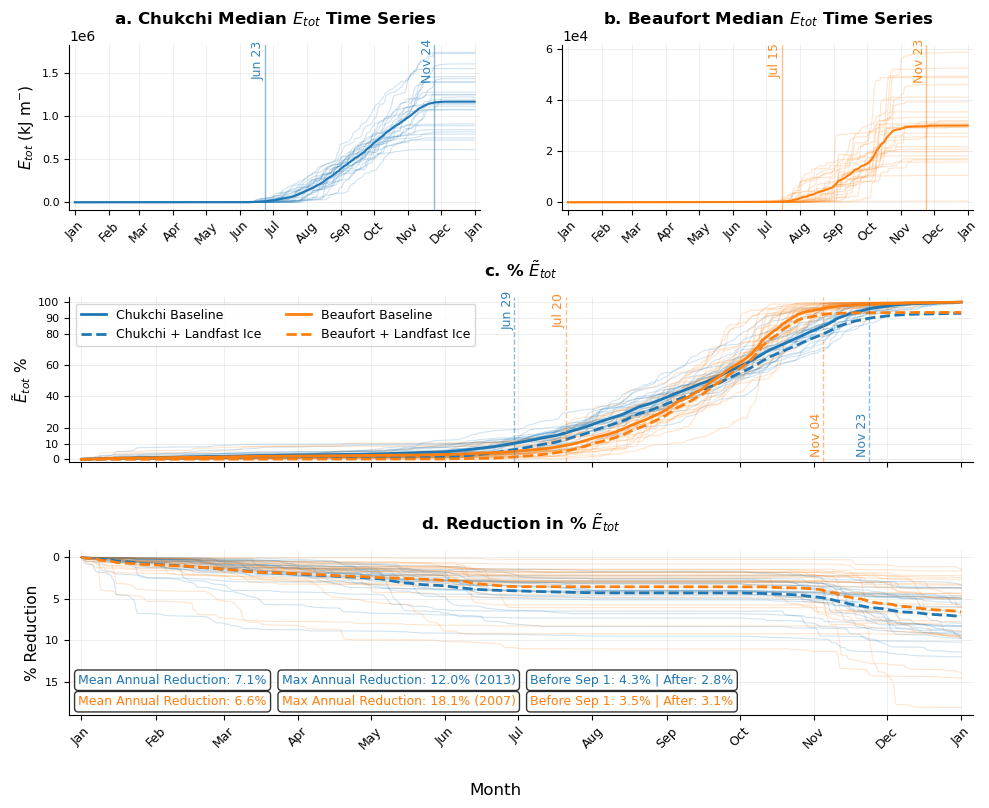

In [8]:


# Create figure with three subplots
fig = plt.figure(figsize=(10,8))
gs = gridspec.GridSpec(3,1, figure=fig)
#ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])

# Create time axes
x = pd.date_range(start='2001-01-01', end='2001-12-31 23:00:00', freq='h')  # Hourly
years = np.arange(1997, 1997 + E0_chukchi.shape[0])





# Common plotting colors
chuk_color = '#1f77b4'
beaufort_color = '#ff7f0e'

# SUBPLOT 1: Energy accumulation time series -- Raw numbers
#define a subgridspec to divide the first subplot into two collumns -- we do this because the y scales are incompatible
gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0, 0])

ax1a = fig.add_subplot(gs1[0, 0])
ax1b = fig.add_subplot(gs1[0, 1])
# # Plot individual years with transparency
for year_idx in range(len(years)):
    ax1a.plot(x, E0_chuk_median[year_idx, :], color=chuk_color, alpha=0.2, linewidth=0.8)
    ax1b.plot(x, E0_beau_median[year_idx, :], color=beaufort_color, alpha=0.2, linewidth=0.8)

# # Plot multi-year averages with thicker lines
ax1a.plot(x, E0_chuk_median.mean(axis=0), label='Chukchi Baseline', color=chuk_color, linestyle='-', linewidth=1.5)
ax1b.plot(x, E0_beau_median.mean(axis=0), label='Beaufort Baseline', color=beaufort_color, linestyle='-', linewidth=1.5)

# Formatting and annotations
Etotstr = r'$E_{tot}$'
Etotnorm = r'$\tilde{E}_{tot}$'
unitstr = r'(kJ m$^{-}$)'
ax1a.set_title(f'a. Chukchi Median {Etotstr} Time Series', fontsize=12, fontweight='bold', pad=15)
ax1a.set_ylabel(f'{Etotstr} {unitstr}', fontsize=11)
ax1b.set_title(f'b. Beaufort Median {Etotstr} Time Series', fontsize=12, fontweight='bold', pad=15)


for ax in [ax1a, ax1b]:
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

#find the 99% Etot for both regions
def find_percentile_indices(data, percents):
    #take the means over years
    annual_mean = data.mean(axis=0)
    final_values = annual_mean[-1]
    
    target_value = []
    for percent in percents:
        target_value.append(final_values * percent / 100)
    percentile_indices = [np.where(annual_mean >= val)[0] for val in target_value]
    return percentile_indices

chuk_pers = find_percentile_indices(E0_chuk_median, [1,99])
beau_pers = find_percentile_indices(E0_beau_median, [1,99])

def add_datelines(ax, region, index, x, linestyle='-', linewidth=1,alpha=0.5,ypos=0.9):
    if region == 'chuk':
        color = '#1f77b4'
    elif region == 'beau':
        color = '#ff7f0e'
    ax.axvline(x=x[index], color=color, linestyle=linestyle, linewidth=linewidth,alpha=alpha)
    str_date = f'{x[index].strftime("%b %d")}'
    ax.text(x=x[index], y=ax.get_ylim()[1]*ypos, s=f'{str_date}', color=color, 
            rotation=90, verticalalignment='center', horizontalalignment='right', alpha=0.9,
            fontsize=9)

add_datelines(ax1a, 'chuk', chuk_pers[1][0], x)
add_datelines(ax1b, 'beau', beau_pers[1][0], x)
add_datelines(ax1a, 'chuk', chuk_pers[0][0], x)
add_datelines(ax1b, 'beau', beau_pers[0][0], x)


# SUBPLOT 2: Mean normalized E0
# Plot individual year Etot % with transparency
for year_idx in range(len(years)):
    E0_chukchi_yr = E0_chukchi[year_idx, :] *100
    E0_beaufort_yr = E0_beaufort[year_idx, :] *100
    ax2.plot(x, E0_chukchi_yr, color=chuk_color, alpha=0.2, linewidth=0.8)
    ax2.plot(x, E0_beaufort_yr, color=beaufort_color, alpha=0.2, linewidth=0.8)

# Plot average Etot % with thicker lines
ax2.plot(x, E0_chukchi.mean(axis=0)*100, label='Chukchi Baseline', color=chuk_color, linewidth=2)
ax2.plot(x, Emask_chukchi.mean(axis=0)*100, label='Chukchi + Landfast Ice', color=chuk_color, linestyle='--', linewidth=2)
ax2.plot(x, E0_beaufort.mean(axis=0)*100, label='Beaufort Baseline', color=beaufort_color, linewidth=2)
ax2.plot(x, Emask_beaufort.mean(axis=0)*100, label='Beaufort + Landfast Ice', color=beaufort_color, linestyle='--', linewidth=2)


chuk_pers = find_percentile_indices(Emask_chuk_median, [1,99])
beau_pers = find_percentile_indices(Emask_beau_median, [1,99])
#plot the datelines
add_datelines(ax2, 'chuk', chuk_pers[1][0], x, linestyle='--',ypos=0.15)
add_datelines(ax2, 'beau', beau_pers[1][0], x, linestyle='--',ypos=0.15)
add_datelines(ax2, 'chuk', chuk_pers[0][0], x, linestyle='--')
add_datelines(ax2, 'beau', beau_pers[0][0], x, linestyle='--')


ax2.legend(fontsize=9, loc='upper left', ncol=2)
yticks = [0,10,20,40,60,80,90,100]
ax2.set_yticks(yticks)
ax2.set_ylim(-2, 103)


# Calculate statistics for annotations
chuk_mean_diff = (E0_chukchi.mean(axis=0)[-1] - Emask_chukchi.mean(axis=0)[-1])*100
beaufort_mean_diff = (E0_beaufort.mean(axis=0)[-1] - Emask_beaufort.mean(axis=0)[-1])*100

chuk_max_diff = (np.max(E0_chukchi[:,-1] - Emask_chukchi[:,-1]))*100
beaufort_max_diff = (np.max(E0_beaufort[:,-1] - Emask_beaufort[:,-1]))*100

# Find years with maximum reduction
chuk_diff = E0_chukchi - Emask_chukchi
beaufort_diff = E0_beaufort - Emask_beaufort
chuk_max_year_idx = np.argmax(chuk_diff[:, -1])
beaufort_max_year_idx = np.argmax(beaufort_diff[:, -1])
chuk_max_year = years[chuk_max_year_idx]
beaufort_max_year = years[beaufort_max_year_idx]



# Formatting
ax2.set_title(f'c. % {Etotnorm}', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel(f'{Etotnorm} %', fontsize=11)


# Take the differences (already calculated above for annotations)

for year_idx in range(len(years)):
    chuk_reduction_yr = chuk_diff[year_idx, :] *100
    beaufort_reduction_yr = beaufort_diff[year_idx, :] *100
    ax3.plot(x, chuk_reduction_yr, color=chuk_color, alpha=0.2, linewidth=0.8)
    ax3.plot(x, beaufort_reduction_yr, color=beaufort_color, alpha=0.2, linewidth=0.8)

chuk_diff_mean = chuk_diff.mean(axis=0) *100
beaufort_diff_mean = beaufort_diff.mean(axis=0) *100
ax3.plot(x, chuk_diff_mean, label='Chukchi Sea', color=chuk_color, linewidth=2, linestyle='--')
ax3.plot(x, beaufort_diff_mean, label='Beaufort Sea', color=beaufort_color, linewidth=2, linestyle='--')


# Calculate mean % reduction before and after Sep 1
sep1_idx = pd.Timestamp('2001-09-01').dayofyear * 24  # Convert to hourly index

# Calculate cumulative reduction at Sep 1 and at year end
chuk_diff_at_sep1 = chuk_diff[:, sep1_idx].mean() * 100
chuk_diff_at_end = chuk_diff[:, -1].mean() * 100
beaufort_diff_at_sep1 = beaufort_diff[:, sep1_idx].mean() * 100
beaufort_diff_at_end = beaufort_diff[:, -1].mean() * 100

# Round to 1 decimal place to ensure displayed values add up correctly
chuk_diff_before_sep = round(chuk_diff_at_sep1, 1)
chuk_diff_total = round(chuk_diff_at_end, 1)
chuk_diff_after_sep = round(chuk_diff_total - chuk_diff_before_sep, 1)

beaufort_diff_before_sep = round(beaufort_diff_at_sep1, 1)
beaufort_diff_total = round(beaufort_diff_at_end, 1)
beaufort_diff_after_sep = round(beaufort_diff_total - beaufort_diff_before_sep, 1)

#add annotations in 2x3 grid layout (rows=regions, cols=mean/max/before-after)
#chukchi
x0,y0 = 0.01, 0.25
xdiff = 0.225
ax3.text(x0, y0, f'Mean Annual Reduction: {chuk_mean_diff:.1f}%', 
         transform=ax3.transAxes, fontsize=9, color=chuk_color, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
         verticalalignment='top', horizontalalignment='left')
ax3.text(x0+xdiff, y0, f'Max Annual Reduction: {chuk_max_diff:.1f}% ({chuk_max_year})', 
         transform=ax3.transAxes, fontsize=9, color=chuk_color, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
         verticalalignment='top', horizontalalignment='left')
ax3.text(x0+xdiff*2+.05, y0, f'Before Sep 1: {chuk_diff_before_sep:.1f}% | After: {chuk_diff_after_sep:.1f}%', 
         transform=ax3.transAxes, fontsize=9, color=chuk_color, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
         verticalalignment='top', horizontalalignment='left')

#Beaufort
x0,y0 = 0.01, y0 - 0.13
xdiff = 0.225
ax3.text(x0,y0, f'Mean Annual Reduction: {beaufort_mean_diff:.1f}%', 
         transform=ax3.transAxes, fontsize=9, color=beaufort_color,
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
         verticalalignment='top', horizontalalignment='left')
ax3.text(x0+xdiff, y0, f'Max Annual Reduction: {beaufort_max_diff:.1f}% ({beaufort_max_year})', 
         transform=ax3.transAxes, fontsize=9, color=beaufort_color,
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
         verticalalignment='top', horizontalalignment='left')
ax3.text(x0+xdiff*2+0.05,y0, f'Before Sep 1: {beaufort_diff_before_sep:.1f}% | After: {beaufort_diff_after_sep:.1f}%', 
         transform=ax3.transAxes, fontsize=9, color=beaufort_color,
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
         verticalalignment='top', horizontalalignment='left')


#formatting
ax3.set_title(f'd. Reduction in % {Etotnorm}', fontsize=12, fontweight='bold', pad=15)
ax3.set_ylabel('% Reduction', fontsize=11)
#ax3.set_xlim([x[0]-pd.Timedelta(days=5), x[-1]+pd.Timedelta(days=5)])
ax3.yaxis.set_inverted(True)



for ax in [ax1a, ax2, ax3, ax1b]:
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    #rotate x-axis labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='center', fontsize = 9)
    plt.setp(ax.get_yticklabels(), fontsize = 8)
    #turn off x axis labels middle plot
    if ax != ax3 and ax != ax1b and ax != ax1a:
         plt.setp(ax.get_xticklabels(), visible=False)
    ax.set_xlim([x[0]-pd.Timedelta(days=5), x[-1]+pd.Timedelta(days=5)])


        




# Set common x-axis label and adjust layout
fig.text(0.5, 0.0, 'Month', ha='center', fontsize=12)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

#save figure
fig.savefig(root / 'Figures' / 'coastal_energy.png', dpi=300, bbox_inches='tight') 
